### Bài 2: Xây dựng kiến trúc Encoder-Decoder gồm 3 lớp LSTM cho module encoder và 3 lớp LSTM cho module decoder, với hidden size là 256, cho bài toán dịch máy từ tiếng Anh sang tiếng Việt. Module decoder được trang bị kỹ thuật attention theo mô tả của nghiên cứu "[Neural Machine Translation by Jointly Learning to Align and Translate](https://arxiv.org/abs/1409.0473)". Huấn luyện mô hình này trên bộ dữ liệu PhoMT sử dụng Adam làm phương thức tối ưu tham số. Đánh giá độ hiệu quả của mô hình sử dụn độ đo ROUGE-L.

In [183]:
!pip install -q rouge-score

In [184]:
# Import các thư viện cần thiết
import os
import sys
import json

import torch
from typing import List, Dict
import numpy as np

base_dir = os.getcwd()
# data_dir = os.path.join(base_dir, 'data', 'small_subset')
colab_dir = os.path.join(base_dir)

# Đọc train/dev/test small subset data
train_data = json.load(open(os.path.join(colab_dir, 'small-train.json'), 'r', encoding='utf-8'))
dev_data = json.load(open(os.path.join(colab_dir, 'small-dev.json'), 'r', encoding='utf-8'))
test_data = json.load(open(os.path.join(colab_dir, 'small-test.json'), 'r', encoding='utf-8'))

print("\nSample train:")
print(type(train_data))
print(train_data[0])


Sample train:
<class 'list'>
{'english': 'It begins with a countdown .', 'vietnamese': 'Câu chuyện bắt đầu với buổi lễ đếm ngược .'}


## 1. Tiền xử lý dữ liệu + TOKENIZE + BUILD VOCAB

In [185]:
import re

def clean_text(text: str):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # bỏ dấu câu
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [186]:
def tokenize(sentence: str):
    """
    Tokenize đơn giản: lowercase + split theo khoảng trắng
    """
    sentence = clean_text(sentence)
    return sentence.split()

In [187]:
print(tokenize("Hello, world! How are you?"))

['hello', 'world', 'how', 'are', 'you']


In [188]:
# Kiểm tra hàm tokenize theo split whitespace và lowercase
print(tokenize(train_data[0]["english"]))
print(tokenize(train_data[0]["vietnamese"]))

['it', 'begins', 'with', 'a', 'countdown']
['câu', 'chuyện', 'bắt', 'đầu', 'với', 'buổi', 'lễ', 'đếm', 'ngược']


### 1.1 Thu thập token từ toàn bộ train set

In [189]:
from collections import Counter

# Counter là một dict đặc biệt để đếm tần số xuất hiện của các phần tử trong một iterable
src_counter = Counter() # src: source language (English)
tgt_counter = Counter() # tgt: target language (Vietnamese)

for sample in train_data:
    src_tokens = tokenize(sample["english"])
    tgt_tokens = tokenize(sample["vietnamese"])

    # Cập nhật counter với các token từ câu hiện tại
    src_counter.update(src_tokens)
    tgt_counter.update(tgt_tokens)

print("Số token tiếng Anh (raw):", len(src_counter))
print("Số token tiếng Việt (raw):", len(tgt_counter))

Số token tiếng Anh (raw): 17252
Số token tiếng Việt (raw): 6883


In [190]:
print(src_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Anh
print(tgt_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Việt

[('the', 15553), ('and', 10979), ('to', 9490), ('of', 8577), ('a', 7837)]
[('và', 9062), ('tôi', 8797), ('là', 8127), ('có', 7399), ('một', 6995)]


### 1.2 Định nghĩa các special tokens

>`eos` đặc biệt cần thiết trong seq2seq khi đánh giá bằng ROUCE-L - vì không có nó, thành phần precision sẽ giảm mạnh do cố gắng sinh thừa từ.

>`bos` sẽ ảnh hưởng nhẹ hơn, nhưng vẫn cần có nó vì nếu không, timestep đầu rất dễ đoán sai, mà LSTM lại phụ thuộc rất nhiều vào hidden_state của step trước.

In [191]:
PAD_TOKEN = "<pad>" # padding 0, cho câu ngắn
BOS_TOKEN = "<bos>" # begin of sentence - Bắt đầu sinh
EOS_TOKEN = "<eos>" # end of sentence - Kết thúc sinh =>
UNK_TOKEN = "<unk>" # unknown token - từ không có trong tập từ điển

SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

### 1.3 Build vocab với `min_freq = 2`

Theo thống kê thì: Phân phối từ vựng xuất hiện nhiều từ hiếm (xuất hiện <1 lần), đặc biệt ở tiếng Anh, ta sẽ áp dụng ngưỡng tần suất tối thiểu khi xây dựng tập từ điển. Cụ thể, min_freq = 2 được sử dụng cho cả hai ngôn ngữ nhằm giảm kích thước từ vựng và hạn chế nhiễu từ các từ hiếm. `Xem chi tiết tại file EDA_PhoMT.ipynb`

English:

- Total vocab: 17414
- Tokens with freq ≤ 1: 7334 (42.12%)
- Tokens with freq ≤ 2: 10016 (57.52%)
- Tokens with freq ≤ 5: 13138 (75.45%)

Vietnamese:

- Total vocab: 7057
- Tokens with freq ≤ 1: 2749 (38.95%)
- Tokens with freq ≤ 2: 3612 (51.18%)
- Tokens with freq ≤ 5: 4543 (64.38%)

In [192]:
def build_vocab(counter, min_freq=2):
    '''
    Build vocabulary từ counter với ngưỡng min_freq
    Input:
        counter: 1 instance Counter đếm tần số token
        min_freq: ngưỡng tần số tối thiểu để token được thêm vào vocab
    Output:
        vocab: list các token trong vocabulary
        token2id: dict mapping token => id
        id2token: dict mapping id => token
    '''
    vocab = SPECIAL_TOKENS.copy()

    for token, freq in counter.items():
        if freq >= min_freq: # mặc định min_freq=2
            vocab.append(token)

    # Tạo mapping token <=> id
    token2id = {token: idx for idx, token in enumerate(vocab)}

    # Tạo mapping id <=> token
    id2token = {idx: token for token, idx in token2id.items()}

    return vocab, token2id, id2token

In [193]:
# Xây dựng vocab + mapping w2i và i2w cho cả 2 ngôn ngữ
src_vocab, src_token2id, src_id2token = build_vocab(src_counter, min_freq=2)
tgt_vocab, tgt_token2id, tgt_id2token = build_vocab(tgt_counter, min_freq=2)

src_vocab[:10] # 10 token đầu trong vocab tiếng Anh

['<pad>',
 '<bos>',
 '<eos>',
 '<unk>',
 'it',
 'begins',
 'with',
 'a',
 'on',
 'august']

In [194]:
# Kiểm tra dạng lưu trữ của token2id và id2token
print(type(src_token2id), type(src_id2token))
print(list(src_token2id.items())[:10])  # 10 mapping token => id đầu tiên
print(list(src_id2token.items())[:10])  # 10 mapping id => token

<class 'dict'> <class 'dict'>
[('<pad>', 0), ('<bos>', 1), ('<eos>', 2), ('<unk>', 3), ('it', 4), ('begins', 5), ('with', 6), ('a', 7), ('on', 8), ('august', 9)]
[(0, '<pad>'), (1, '<bos>'), (2, '<eos>'), (3, '<unk>'), (4, 'it'), (5, 'begins'), (6, 'with'), (7, 'a'), (8, 'on'), (9, 'august')]


In [195]:
print("SRC vocab size:", len(src_vocab))
print("TGT vocab size:", len(tgt_vocab))

SRC vocab size: 10025
TGT vocab size: 4253


>Ta thấy giảm đáng kể vocab size:
- Số token tiếng Anh (raw): 17414 còn 10084
- Số token tiếng Việt (raw): 7057 còn 4312

=> Ta chấp nhận sự đánh đổi này, vì mô hình sẽ đỡ nặng hơn và đỡ học phải nhiễu (Xem thêm tại file EDA_PhoMT.ipynb)

### 1.4 Mapping câu => sequence id (chưa padding)

In [196]:
def numericalize(tokens: List[str], token2id: Dict[str, int]) -> List[int]:
    '''
    Chuyển danh sách token thành danh sách id tương ứng:
    Input:
        tokens: list các token
        token2id: dict mapping token => id
    Output:
        list các id tương ứng với token
    '''
    return [
        token2id.get(token, token2id[UNK_TOKEN])
        for token in tokens
    ]

In [197]:
sample = train_data[0]

# Chuyển câu sample sang dạng id
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Sample sentence (ENG):", sample["english"])
print("SRC ids:", src_ids)

print("Sample sentence (VIE):", sample["vietnamese"])
print("TGT ids:", tgt_ids)

Sample sentence (ENG): It begins with a countdown .
SRC ids: [4, 5, 6, 7, 3]
Sample sentence (VIE): Câu chuyện bắt đầu với buổi lễ đếm ngược .
TGT ids: [4, 5, 6, 7, 8, 9, 10, 11, 12]


## 2. PADDING + DATASET + DATALOADER

In [198]:
MAX_SRC_LEN = 70 # Xem file EDA_PhoMT.ipynb
MAX_TGT_LEN = 85 # Xem file EDA_PhoMT.ipynb

PAD_ID = src_token2id[PAD_TOKEN]
BOS_ID = tgt_token2id[BOS_TOKEN]
EOS_ID = tgt_token2id[EOS_TOKEN]
UNK_ID = tgt_token2id[UNK_TOKEN]

print(PAD_ID, BOS_ID, EOS_ID, UNK_ID)

0 1 2 3


### 2.1 Padding và truncate sequence

In [199]:
def pad_sequence(seq: List[int], max_len: int, pad_id: int) -> List[int]:
    """
    Right-padding hoặc truncate sequence
    Input:
        seq: list các id (int)
        max_len: độ dài tối đa của sequence sau khi padding/truncate
        pad_id: id dùng để padding
    Return:
        list các id có độ dài = max_len
    """
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))

In [200]:
# Ví dụ pad/truncate
sample = train_data[0]
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Original SRC ids length:", len(src_ids))
padded_src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)
print("Padded SRC ids length:", len(padded_src_ids))

print("Original TGT ids length:", len(tgt_ids))
padded_tgt_ids = pad_sequence(tgt_ids, MAX_TGT_LEN, PAD_ID)
print("Padded TGT ids length:", len(padded_tgt_ids))

Original SRC ids length: 5
Padded SRC ids length: 70
Original TGT ids length: 9
Padded TGT ids length: 85


### 2.2 Xử lý target sequence

In [201]:
def process_target(tokens: List[str], token2id: Dict[str, int], max_len: int) -> List[int]:
    """
    Xử lý target sequence: thêm BOS/EOS, numericalize, pad/truncate
    Input:
        tokens: list các token (str)
        token2id: dict mapping token => id
        max_len: độ dài tối đa của sequence sau khi padding/truncate
    Return:
        list các id có độ dài = max_len
     <bos> w1 w2 ... wn <eos>
    """
    ids = [BOS_ID] + numericalize(tokens, token2id) + [EOS_ID]
    return pad_sequence(ids, max_len, PAD_ID)

### 2.3 Tạo Dataset và DataLoader

In [202]:
import torch
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    '''
    PyTorch Dataset cho bài toán dịch máy tiếng Anh sang tiếng Việt.
    '''
    def __init__(self, data, src_token2id, tgt_token2id):
        self.data = data # list các sample, mỗi sample là dict {"english": ..., "vietnamese": ...}
        self.src_token2id = src_token2id
        self.tgt_token2id = tgt_token2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Lấy một sample đã được tokenize, numericalize và padding.

        Input:
            idx (int): chỉ số của sample

        Output:
            dict:
                "src": LongTensor (MAX_SRC_LEN,)
                "tgt": LongTensor (MAX_TGT_LEN,)
        """
        sample = self.data[idx]

        # Source
        src_tokens = tokenize(sample["english"])
        src_ids = numericalize(src_tokens, self.src_token2id)
        src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)

        # Target
        tgt_tokens = tokenize(sample["vietnamese"])
        tgt_ids = process_target(tgt_tokens, self.tgt_token2id, MAX_TGT_LEN)
        # Chỉ có target mới cần thêm BOS/EOS bằng hàm process_target - vì nó dùng để sinh câu - Decoding

        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "tgt": torch.tensor(tgt_ids, dtype=torch.long)
        }

In [203]:
from torch.utils.data import DataLoader

train_dataset = TranslationDataset(train_data, src_token2id, tgt_token2id)
dev_dataset   = TranslationDataset(dev_data, src_token2id, tgt_token2id)
test_dataset  = TranslationDataset(test_data, src_token2id, tgt_token2id)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=64,
    shuffle=False
)

In [204]:
# Kiểm tra thử
batch = next(iter(train_loader))
print(batch["src"].shape)  # [32, 70]
print(batch["tgt"].shape)  # [32, 85]

print(batch["tgt"][0])

torch.Size([64, 70])
torch.Size([64, 85])
tensor([  1, 557,  49,  72, 370, 573, 723,  58,   2,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0])


>`bos = 1` | `eos = 2` | `padding = 0`

## 3. MODEL ENCODER–DECODER LSTM

English ids
=> Embedding (256)
=> Encoder LSTM (3 layers, hidden=256)
=> hidden, cell
=> Decoder LSTM (3 layers, hidden=256)
=>  Linear
=>  Vietnamese vocab logits


### 3.1 Encoder 3-layer LSTM

In [205]:
import torch.nn as nn

class Encoder(nn.Module):
    """
    Encoder LSTM cho bài toán dịch máy.

    Input:
        src: Tensor shape (batch_size, src_len)
    Output:
        hidden, cell: Tensor shape (num_layers, batch_size, hidden_size)
    """

    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=3):
        super().__init__()

        # Layer 1: Embedding
        # Chuyển word indices (số nguyên) thành vector ngữ nghĩa liên tục
        # (ví dụ chữ cat được encode là 31, thì embedding sẽ chuyển 31 thành vector liên tục có chiều dài là embedding_dim)
        # Input: [batch_size, seq_len] → Output: [batch_size, seq_len, embedding_dim]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, # Số từ trong vocab
            embedding_dim=embed_dim, # Chiều dài embedding
            padding_idx=PAD_ID # ID dùng để padding - thường là 0
        )

        # Layer 2: LSTM
        # Xử lý tuần tự các embedding vectors
        # Input: [batch_size, seq_len, embedding_dim] - có được từ layer Embedding
        # Output: [batch_size, seq_len, hidden_size] (nếu return_sequences=True)
        # Hidden/Cell: [num_layers, batch_size, hidden_size]
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        # src: [batch_size, seq_len] - 1 vector (batch_size) of word indices (biểu diễn số của từng từ trong câu)
        embedded = self.embedding(src)          # (B, src_len, 256)
        # print(f"[Encoder] After embedding: {embedded.shape}")
        # Output shape: [batch_size, seq_len, embed_dim]

        encoder_outputs, (hidden, cell) = self.lstm(embedded)
        # outputs (encoder_outputs):
        #   Hidden states của LSTM tại TẤT CẢ timesteps,
        #   nhưng CHỈ của layer trên cùng (top layer)
        #   Shape: (batch_size, src_len, hidden_size)

        # hidden:
        #   Hidden state tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # cell:
        #   Cell state (long-term memory) tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # print(f"[Encoder] After LSTM - output: {outputs.shape}, hidden: {hidden.shape}")

        # Return hidden & cell state
        # Cái này sẽ dùng làm initial state cho Decoder
        return encoder_outputs, hidden, cell

### 3.2 Attention class

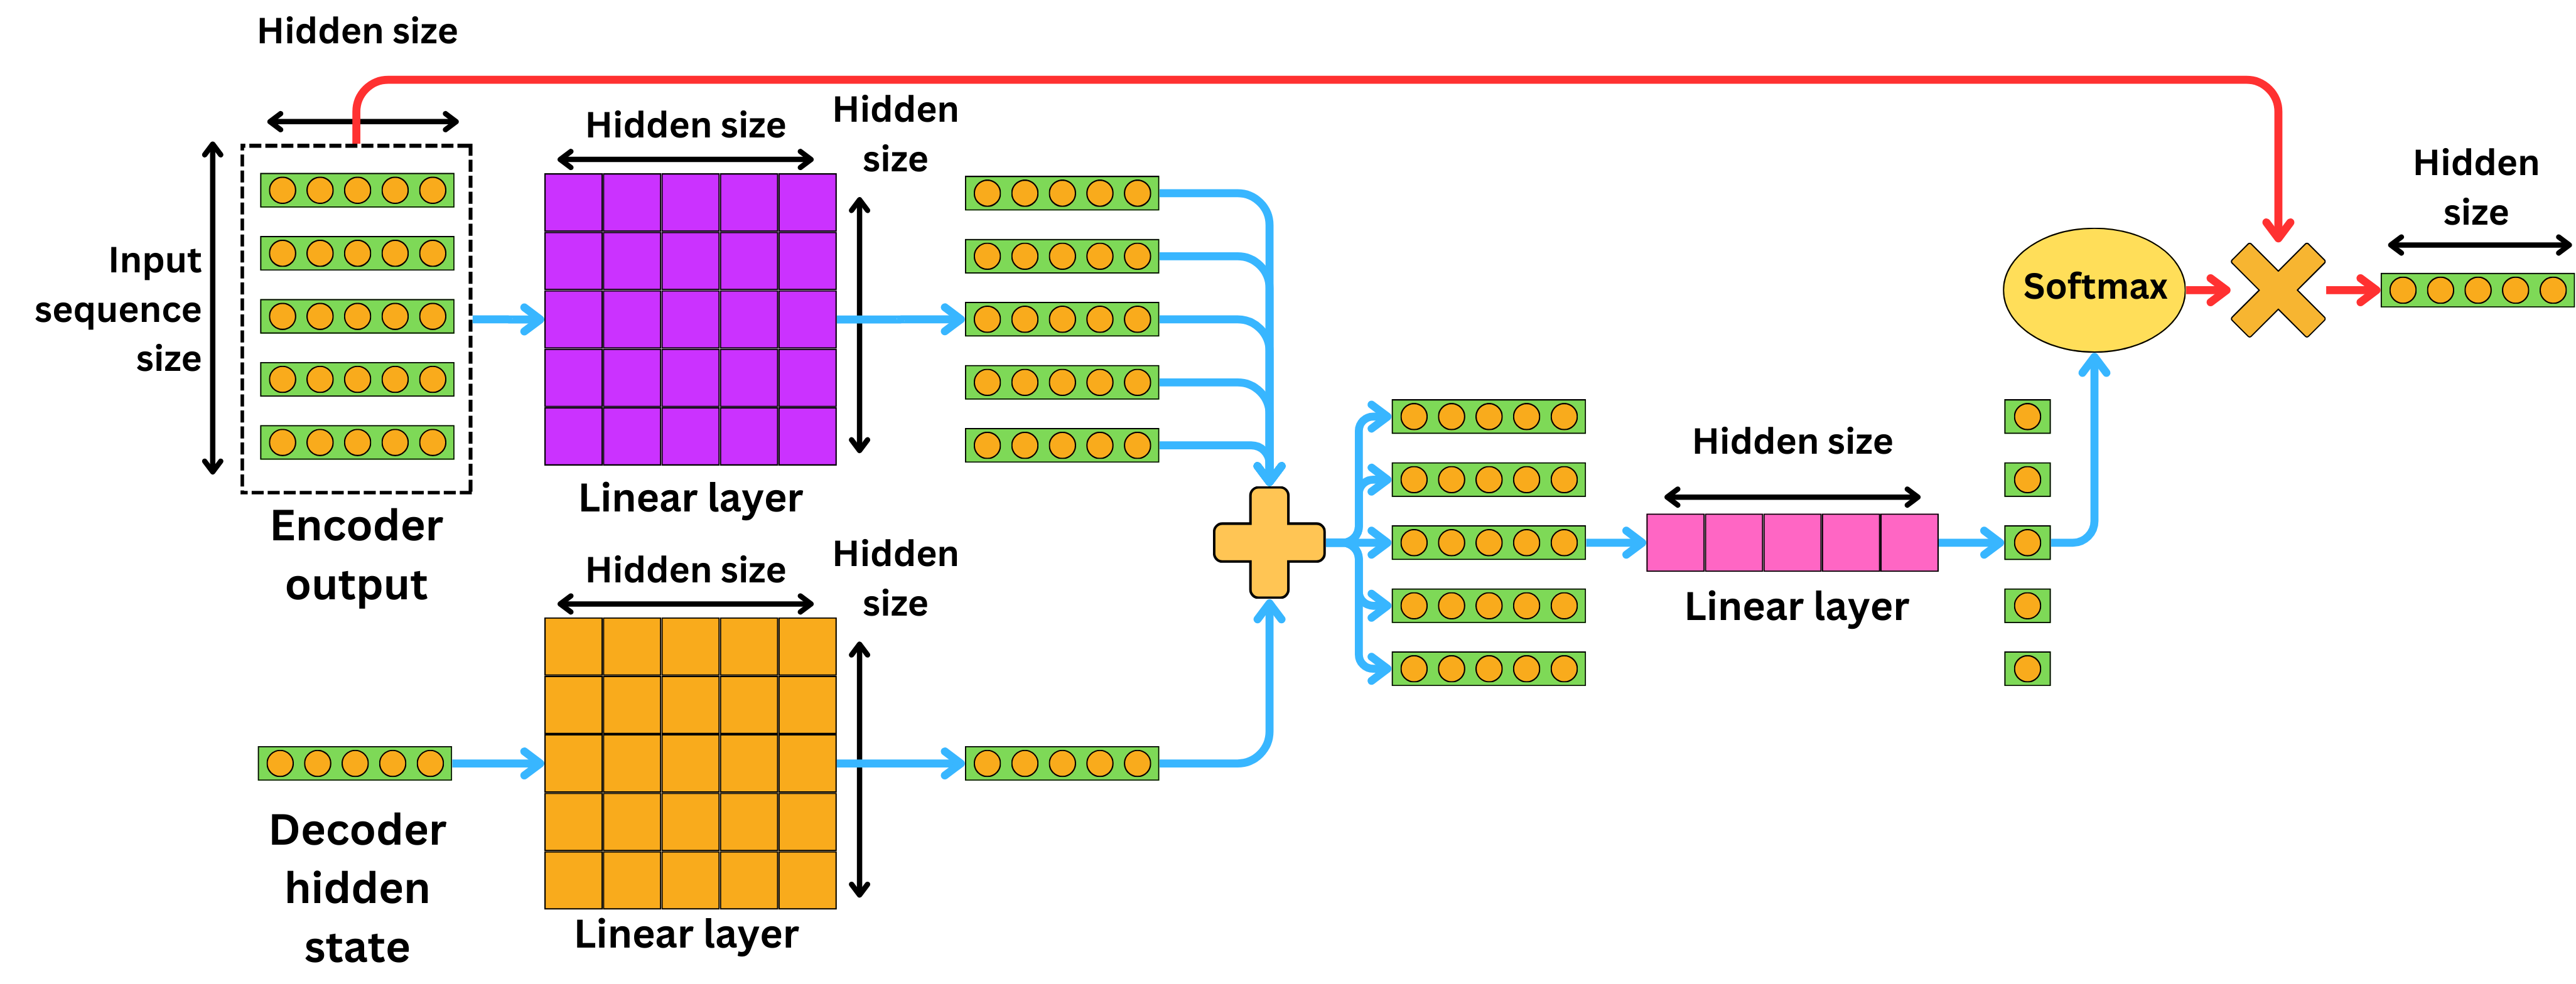

Flow quy trình:

1. encoder outputs - $h_i$ (`[batch, src_len, hidden_size]`) và decoder hidden state $s_t$ (`[batch, hidden_size]`) sẽ được truyền qua 2 lớp linear giống nhau về mặt tham số (`[hidden_size, hidden_size]`)

>- Khối Linear màu tím (encoder side): W_k

>- Khối Linear màu cam (decoder side): W_q

`W_k, W_q` là 2 ma trận trọng số, nó sẽ nhân cho `h_i và s_t`, rồi qua quá trình lan truyền ngược, 2 ma trận này sẽ có thay đổi các số bên trong, nó sẽ làm sao cho phép nhân W với `h_i / s_t` cho kết quả tốt (biết chú ý đúng từ)

```python
- self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)
- self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)
```  

2. chuẩn bị cộng 2 cái output của 2 ma trận trên (2 lớp linear)

Để cộng được đầu tiên phải đảm bảo đúng chiều, thì ta sẽ nhân ma trận `W_k / W_q` với `h_i / s_t`, nhưng do ma trận W có `shape=(256, 256)` nên chiều vẫn như cũ, nên không sao.
> - encoder = $W_k$ * $h_i$ - mỗi từ nguồn ($W_k$ * 1 vector các từ đã qua encoder) => 1 vector đã `attention`  (xét 1 batch)
> - decoder = $W_q$ * $s_t$ - câu hỏi của decoder, nên lúc sau ta phải add thêm 1 chiều (xét 1 batch)

```python
- keys = self.W_k(encoder_outputs)  # [batch_size, src_len, hidden_size]
- query = self.W_q(decoder_hidden).unsqueeze(1)  # ta thêm 1 chiều để giống chiều với keys để lát có thể cộng lại được [batch_size, 1, hidden_size]`
```  

3. Tính scores: score = v^T * tanh(W_q * s_t + W_k * h_i) +  đưa qua lớp linear 1 chiều


```python
energy = torch.tanh(query + keys)  # [batch_size, src_len, hidden_size]
scores = self.v(energy).squeeze(2)  # [batch_size, src_len]

# Trước đó đã khai báo
self.v = nn.Linear(hidden_size, 1, bias=False)  # Scoring function
```
> Đại diện cho decoder ở thời điểm t chú ý từ i bao nhiêu - lớp linear màu hồng và cột xanh lá bên phải.

4. Đưa qua soft-max
trả về dim = 1 <=> vector xác suất gồm n phần tử (n là seq_len), đại diện cho từ nào sẽ chú ý nhiều.

```python
attention_weights = torch.softmax(scores, dim=1)  # [batch_size, src_len]
```

5. Tính Weighted sum

> - Lấy trung bình có trọng số các $h_i$

> - Trọng số cao => từ đó được chú ý nhiều hơn

=> Trả về 1 context vector (trung bình có trọng số của các $h_i$) đại diện cho một bản tóm tắt có chọn lọc của encoder outputs, phụ thuộc vào decoder đang định viết gì

```python
context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
# [batch_size, 1, src_len] x [batch_size, src_len, hidden_size] -> [batch_size, hidden_size]
```

In [206]:
class BahdanauAttention(nn.Module):
    """
    Bahdanau Attention (Additive Attention)

    Công thức:
    score(s_t, h_i) = v^T * tanh(W_q * s_t + W_k * h_i)
    """
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.hidden_size = hidden_size

        self.W_q = nn.Linear(hidden_size, hidden_size, bias=False)  # Query projection
        self.W_k = nn.Linear(hidden_size, hidden_size, bias=False)  # Key projection
        self.v = nn.Linear(hidden_size, 1, bias=False)  # Scoring function

    def forward(self, decoder_hidden, encoder_outputs):
        """
        Args:
            decoder_hidden: [batch_size, hidden_size] - s_t
            encoder_outputs: [batch_size, src_len, hidden_size] - {h_i}

        Returns:
            context: [batch_size, hidden_size]
            attention_weights: [batch_size, src_len]
        """
        # Tính scores: score = v^T * tanh(W_q * s_t + W_k * h_i)
        query = self.W_q(decoder_hidden).unsqueeze(1)  # [batch_size, 1, hidden_size]
        keys = self.W_k(encoder_outputs)  # [batch_size, src_len, hidden_size]

        # Additive attention
        energy = torch.tanh(query + keys)  # [batch_size, src_len, hidden_size]
        scores = self.v(energy).squeeze(2)  # [batch_size, src_len]

        # Softmax
        attention_weights = torch.softmax(scores, dim=1)  # [batch_size, src_len]

        # Weighted sum
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        # [batch_size, 1, src_len] x [batch_size, src_len, hidden_size] -> [batch_size, hidden_size]

        return context, attention_weights

### 3.3 Decoder 3-layer LSTM

In [207]:
class DecoderAttention(nn.Module):
    """
    Decoder với Bahdanau Attention cho Bài 2
    """
    def __init__(self, vocab_size, embedding_dim=256, hidden_size=256,
                 num_layers=5, dropout=0.3):
        super(DecoderAttention, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = BahdanauAttention(hidden_size)

        # Output: kết hợp LSTM output với context vector
        self.fc = nn.Linear(hidden_size * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs):
        """
        Args:
            input_token: [batch_size, 1]
            hidden: [num_layers, batch_size, hidden_size]
            cell: [num_layers, batch_size, hidden_size]
            encoder_outputs: [batch_size, src_len, hidden_size]

        Returns:
            prediction: [batch_size, vocab_size]
            hidden, cell: state mới
            attention_weights: [batch_size, src_len]
        """
        embedded = self.dropout(self.embedding(input_token))  # [batch_size, 1, embedding_dim]

        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: [batch_size, 1, hidden_size]

        # Attention
        decoder_hidden = hidden[-1]  # Lấy hidden state lớp cuối
        context, attention_weights = self.attention(decoder_hidden, encoder_outputs)

        # Kết hợp output với context
        combined = torch.cat([output.squeeze(1), context], dim=1)  # [batch_size, hidden_size*2]
        prediction = self.fc(combined)  # [batch_size, vocab_size]

        return prediction, hidden, cell, attention_weights

### 3.4 Seq2Seq wrapper ghép Encoder + Decoder

In [208]:
import random

class Seq2Seq(nn.Module):
    """
    Seq2Seq wrapper cho Encoder + DecoderAttention (Bahdanau)

    - Encoder đọc toàn bộ câu nguồn
    - Decoder sinh câu đích từng timestep (auto-regressive)
    """

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        Args:
            src: [batch_size, src_len]
            tgt: [batch_size, tgt_len] (có <BOS> ở đầu)
        Returns:
            outputs: [batch_size, tgt_len-1, vocab_size]
        """

        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        vocab_size = self.decoder.fc.out_features

        # =====================
        # 1. ENCODER
        # =====================
        encoder_outputs, hidden, cell = self.encoder(src)
        # encoder_outputs: [B, src_len, hidden]
        # hidden, cell:    [num_layers, B, hidden]

        # =====================
        # 2. DECODER
        # =====================
        decoder_input = tgt[:, 0].unsqueeze(1)  # <BOS>
        outputs = []

        for t in range(1, tgt_len):
            prediction, hidden, cell, _ = self.decoder(
                decoder_input,
                hidden,
                cell,
                encoder_outputs
            )
            # prediction: [B, vocab_size]

            outputs.append(prediction.unsqueeze(1))

            # teacher forcing
            use_teacher_forcing = random.random() < teacher_forcing_ratio
            top_token = prediction.argmax(dim=1)

            decoder_input = (
                tgt[:, t].unsqueeze(1)
                if use_teacher_forcing
                else top_token.unsqueeze(1)
            )

        outputs = torch.cat(outputs, dim=1)
        # [B, tgt_len-1, v_]()
        return outputs

    @torch.no_grad()
    def predict(self, src, max_len=100):
      """
      Greedy decoding cho Seq2Seq + Attention

      Args:
          src: [batch_size, src_len]
      Returns:
          outputs: [batch_size, decoded_len]
      """
      self.eval()
      device = src.device
      batch_size = src.size(0)

      # ----- Encoder -----
      encoder_outputs, hidden, cell = self.encoder(src)

      # ----- Decoder -----
      decoder_input = torch.full(
          (batch_size, 1),
          BOS_ID,          # <BOS>
          dtype=torch.long,
          device=device
      )

      outputs = []
      finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

      for _ in range(max_len):
          prediction, hidden, cell, _ = self.decoder(
              decoder_input,
              hidden,
              cell,
              encoder_outputs
          )
          # prediction: [B, vocab_size]

          top1 = prediction.argmax(dim=1)  # [B]
          outputs.append(top1.unsqueeze(1))

          decoder_input = top1.unsqueeze(1)
          finished |= (top1 == EOS_ID)

          if finished.all():
              break

      outputs = torch.cat(outputs, dim=1)
      return outputs

In [209]:
SRC_VOCAB_SIZE = len(src_token2id)
TGT_VOCAB_SIZE = len(tgt_token2id)

encoder = Encoder(
    vocab_size=SRC_VOCAB_SIZE,
    embed_dim=256,
    hidden_size=256,
    num_layers=3
)

decoder = DecoderAttention(
    vocab_size=TGT_VOCAB_SIZE,
    embedding_dim=256,
    hidden_size=256,
    num_layers=3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Seq2Seq(encoder, decoder).to(device)

batch = next(iter(train_loader))
out = model(
    batch["src"].to(device),
    batch["tgt"].to(device)
)

print(out.shape)

torch.Size([64, 84, 4253])


## 4. TRAINING LOOP (Seq2Seq + Adam)

### 4.1 Chuẩn bị loss & optimizer

In [210]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

> Lưu ý quan trọng: ignore `<pad>` là bắt buộc. Nếu không, model sinh `<pad>` sớm => câu toàn kí tự `<pad>` => ROUGE-L tụt (do thành phần LCS prediction + recall tụt). Do thông thường kí hiệu `<pad>` xuất hiện rất nhiều - do câu ngắn chiếm đa số (ngắn hơn tgt_len), nếu không ignore `<pad>`, model sẽ cố gắng an toàn sinh ra toàn các `<pad>` sớm, gây mất nhiều từ quan trọng và câu bị ngắn đi.

### 4.2 Hàm train 1 epoch

In [211]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    teacher_forcing_ratio=0.5,
    device="cpu"
):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        optimizer.zero_grad()

        # Forward: Seq2Seq
        outputs = model(
            src,
            tgt,
            teacher_forcing_ratio=teacher_forcing_ratio
        )
        # outputs: (B, tgt_len-1, vocab_size)

        output_dim = outputs.size(-1)

        # Shift target: bỏ <BOS>
        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

- `tgt[:, 1:]` là label

- `<bos>` không được tính loss

- `<pad>` bị ignore

### 4.3 Hàm validation (KHÔNG teacher forcing)

In [212]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device="cpu"):
    model.eval()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        outputs = model(src, tgt, teacher_forcing_ratio=0.0)

        output_dim = outputs.size(-1)
        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)
        total_loss += loss.item()

    return total_loss / len(dataloader)

### 4.4 Hàm tính ROUGE-L

In [213]:
from rouge_score import rouge_scorer
from tqdm import tqdm

@torch.no_grad()
def evaluate_rouge_l(model, dataloader, device):
    model.eval()
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    scores = []

    for batch in tqdm(dataloader, desc="Evaluating ROUGE-L"):
        src = batch["src"].to(device)
        tgt = batch["tgt"]  # để decode, không cần .to(device)

        preds = model.predict(src)  # [B, pred_len]

        for i in range(src.size(0)):
            pred_sentence = decode_ids_to_sentence(preds[i].cpu().tolist())
            tgt_sentence  = decode_ids_to_sentence(tgt[i, 1:].tolist())  # bỏ <BOS>

            score = scorer.score(tgt_sentence, pred_sentence)
            scores.append(score["rougeL"].fmeasure)

    return sum(scores) / len(scores)

### 4.5 Hàm decode - chuyển list token ids thành câu string


In [214]:
def decode_ids_to_sentence(ids, id2token=tgt_id2token):
    """
    Chuyển list token ids => câu string

    Args:
        ids: List[int]
    Returns:
        sentence: str
    """
    tokens = []
    for idx in ids:
        if idx == EOS_ID:
            break
        if idx in (PAD_ID, BOS_ID):
            continue
        tokens.append(id2token.get(idx, "<unk>"))

    return " ".join(tokens)

In [215]:
batch = next(iter(dev_loader))
preds = model.predict(batch["src"].to(device))

print("PRED:", decode_ids_to_sentence(preds[0].cpu().tolist()))
print("GT  :", decode_ids_to_sentence(batch["tgt"][0, 1:].tolist()))

PRED: 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000 80000
GT  : vào chủ nhật ngày <unk> cơn bão <unk> một trong những cơn bão mạnh nhất được ghi nhận ở đại tây dương với sức gió <unk> <unk> đổ bộ vào đảo great <unk> miền bắc <unk>


### 4.6 Training loop tổng

In [216]:
# tăng tốc training
torch.backends.cudnn.benchmark = True

In [217]:
best_rouge_l = -1.0
BEST_MODEL_PATH = "best_seq2seq_rougeL.pt"

train_losses = []
val_losses = []
val_rouge_ls = []

In [218]:
N_EPOCHS = 15

for epoch in range(1, N_EPOCHS + 1):

    # ---- scheduled teacher forcing ----
    teacher_forcing_ratio = max(0.5 - epoch * 0.05, 0.1)

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        teacher_forcing_ratio=teacher_forcing_ratio,
        device=device
    )

    val_loss = evaluate(
        model,
        dev_loader,
        criterion,
        device=device
    )

    rouge_l = evaluate_rouge_l(
        model,
        dev_loader,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rouge_ls.append(rouge_l)

    # ---- SAVE BEST MODEL BY ROUGE-L ----
    if rouge_l > best_rouge_l:
        best_rouge_l = rouge_l
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        improved = "🔥 saved"
    else:
        improved = ""

    print(f"Epoch {epoch:02d}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f}")
    print(f"  ROUGE-L   : {rouge_l:.4f} {improved}")

Evaluating ROUGE-L: 100%|██████████| 32/32 [00:01<00:00, 26.50it/s]


Epoch 01
  Train loss: 6.3078
  Val   loss: 6.3808
  ROUGE-L   : 0.1982 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:03<00:00,  9.63it/s]


Epoch 02
  Train loss: 6.0672
  Val   loss: 6.2325
  ROUGE-L   : 0.2229 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:03<00:00,  9.18it/s]


...

Epoch 13
  Train loss: 3.8791
  Val   loss: 5.6424
  ROUGE-L   : 0.3593 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:03<00:00,  8.13it/s]


Epoch 14
  Train loss: 3.7343
  Val   loss: 5.6988
  ROUGE-L   : 0.3640 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:04<00:00,  7.44it/s]

Epoch 15
  Train loss: 3.6060
  Val   loss: 5.7709
  ROUGE-L   : 0.3676 🔥 saved


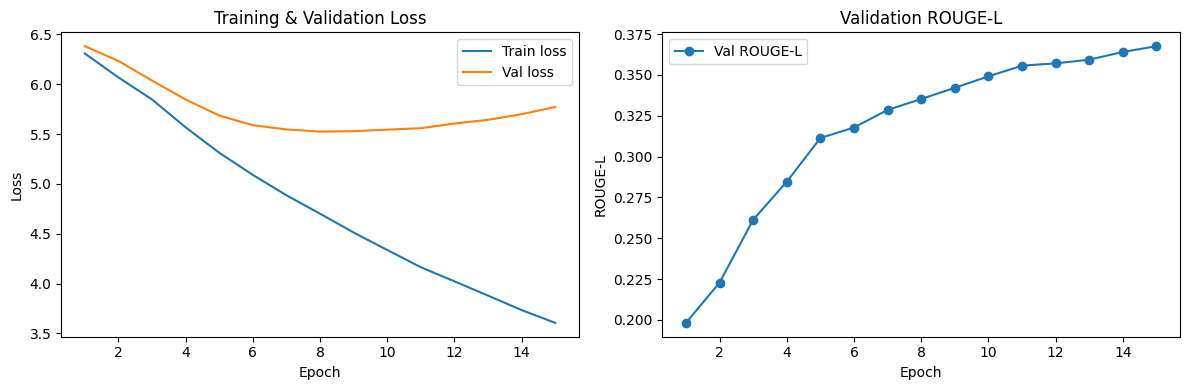

In [219]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# ---- ROUGE-L ----
plt.subplot(1, 2, 2)
plt.plot(epochs, val_rouge_ls, marker="o", label="Val ROUGE-L")
plt.xlabel("Epoch")
plt.ylabel("ROUGE-L")
plt.title("Validation ROUGE-L")
plt.legend()

plt.tight_layout()
plt.show()

>Chỉ số val hầu như không có tác động tới độ đo ROUGE-L, khi val loss tăng, train loss giảm (dấu hiệu over fitting) nhưng ROUGE-L vẫn có xu hướng tăng. Vẫn có thể cải thiện nếu train thêm epoch

## 5. Inference + ROUGE-L evaluation

In [220]:
test_dataset = TranslationDataset(
    test_data,
    src_token2id,
    tgt_token2id
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [221]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

test_rouge_l = evaluate_rouge_l(
    model,
    test_loader,
    device=device
)

print(f"Test ROUGE-L: {test_rouge_l:.4f}")

Evaluating ROUGE-L: 100%|██████████| 63/63 [00:06<00:00,  9.85it/s]

Test ROUGE-L: 0.3738


> Test ROUGE-L: 0.3738 là 1 con số khả quan hơn so với khi không có attention

In [225]:
# In vài câu dự đoán để quan sát chất lượng dịch
model.eval()

num_samples = 5
batch = next(iter(dev_loader))

src = batch["src"].to(device)
tgt = batch["tgt"]

preds = model.predict(src)

print("=" * 80)
for i in range(num_samples):
    src_sentence = decode_ids_to_sentence(
        batch["src"][i].tolist(),
        id2token=src_id2token   # vocab tiếng Anh
    )
    tgt_sentence = decode_ids_to_sentence(
        tgt[i, 1:].tolist(),    # bỏ <BOS>
        id2token=tgt_id2token
    )
    pred_sentence = decode_ids_to_sentence(
        preds[i].cpu().tolist(),
        id2token=tgt_id2token
    )

    print(f"[SRC ] {src_sentence}")
    print(f"[GT  ] {tgt_sentence}")
    print(f"[PRED] {pred_sentence}")
    print("-" * 80)

[SRC ] hurricane <unk> one of the most powerful <unk> ever recorded in the atlantic ocean made <unk> as a category 5 storm on great <unk> island in the northern <unk> on sunday morning september 1 <unk>
[GT  ] vào chủ nhật ngày <unk> cơn bão <unk> một trong những cơn bão mạnh nhất được ghi nhận ở đại tây dương với sức gió <unk> <unk> đổ bộ vào đảo great <unk> miền bắc <unk>
[PRED] <unk> <unk> một trong những trong lớn lớn lớn lớn nhất nhất nhất ở tây tây tây tây nơi không không <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> ở <unk> <unk> <unk> <unk> ngàn ngàn tháng
--------------------------------------------------------------------------------
[SRC ] <unk> is especially dangerous due to its slow movement high wind speeds and heavy <unk>
[GT  ] bão <unk> đặc biệt nguy hiểm vì nó di chuyển chậm có tốc độ gió cao và gây mưa lớn
[PRED] <unk> là là là bi nguy hiểm hiểm hiểm để chậm chậm tốc gió gió gió và và linh và và và và
----------------------------------------------------